In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../../output/cl_only.csv", )

In [3]:
pd.unique(df.metric)

array(['train/total_loss', 'test/acc', 'hist_test/acc', 'cperf/fwd_flop',
       'cperf/fwd_time', 'cperf/fwd_flops', 'cperf/bwd_flop',
       'cperf/bwd_time', 'cperf/bwd_flops', 'cperf/optim_flop',
       'cperf/optim_time', 'cperf/optim_flops', 'hist_train/total_loss',
       'hist_train/forgetting_loss', 'hist_train/generation_loss',
       'cperf/hamiltonian_flop', 'cperf/hamiltonian_time',
       'cperf/hamiltonian_flops'], dtype=object)

In [4]:
pivot_df = df.pivot(index='step', columns='metric', values='value')

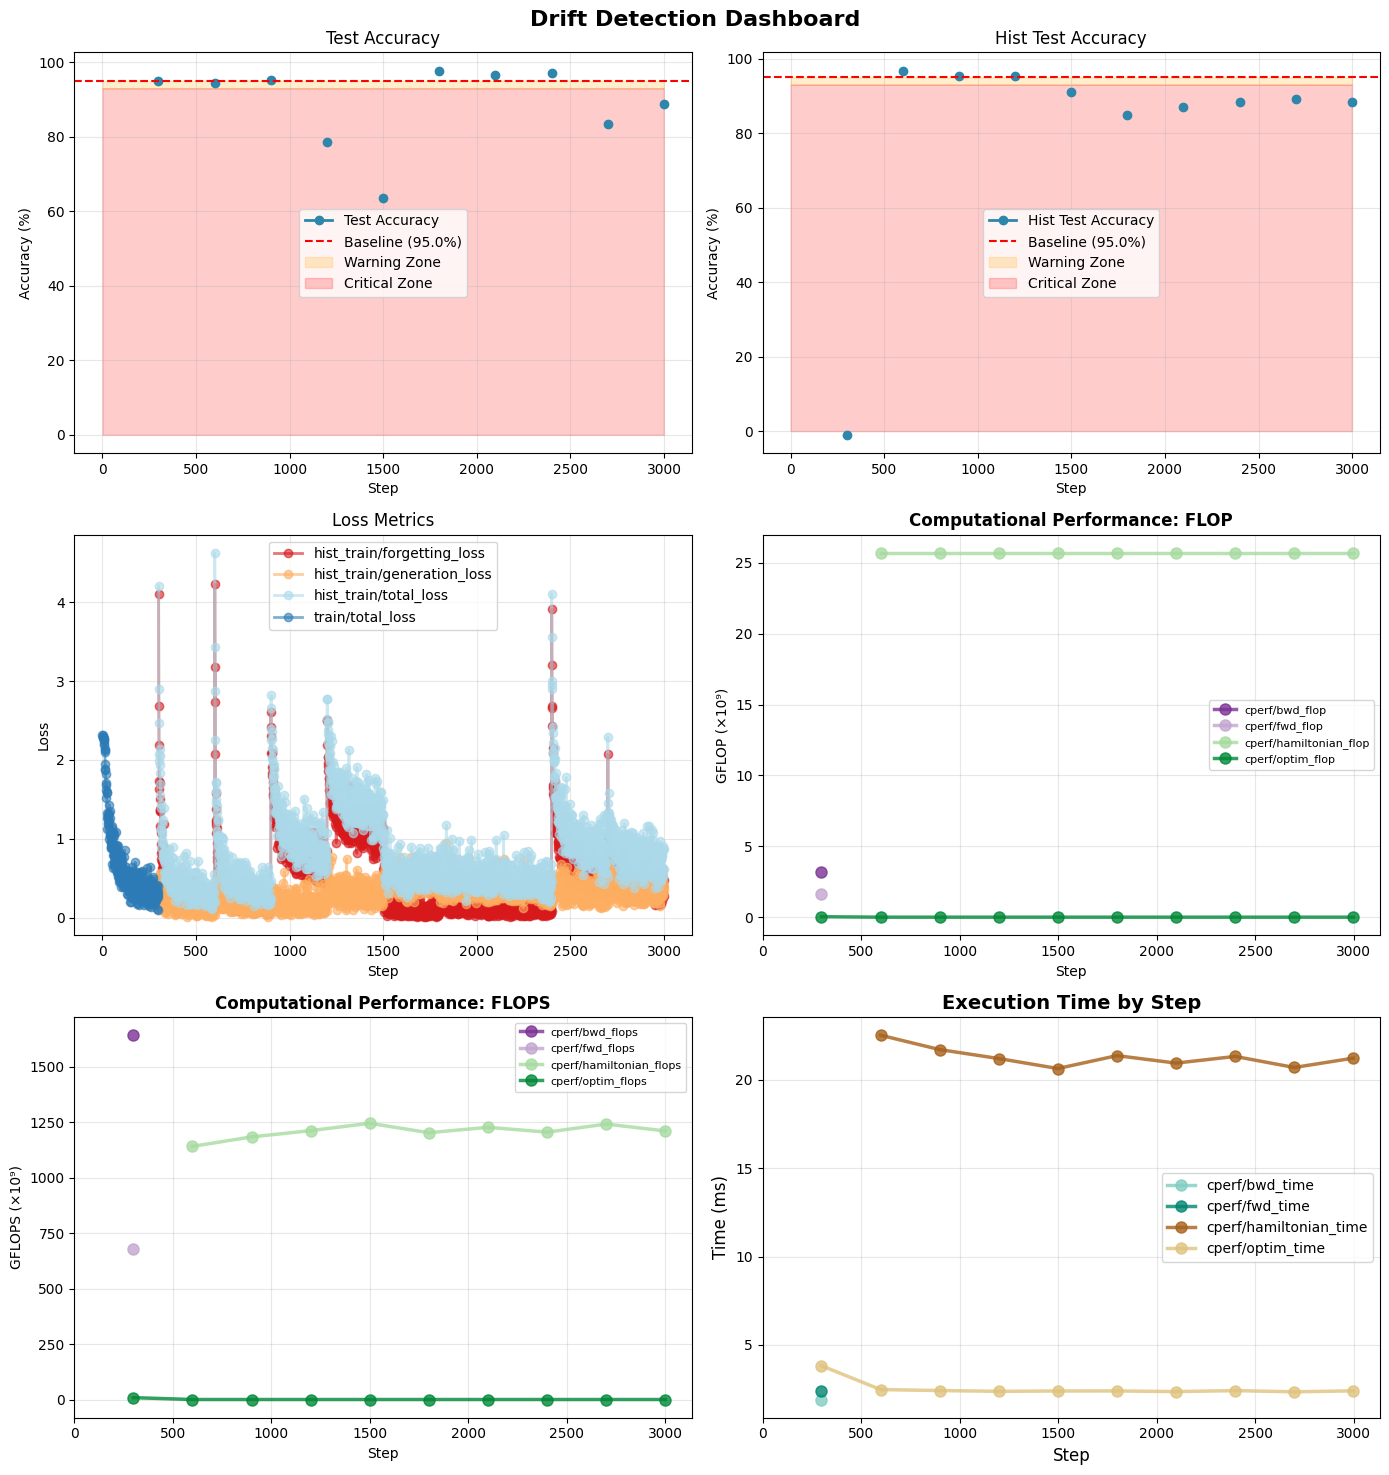


=== Execution Time Analysis ===

cperf/bwd_time:
  Mean: 1.918 ms
  Min:  1.918 ms
  Max:  1.918 ms

cperf/fwd_time:
  Mean: 2.399 ms
  Min:  2.399 ms
  Max:  2.399 ms

cperf/hamiltonian_time:
  Mean: 21.283 ms
  Min:  20.629 ms
  Max:  22.512 ms

cperf/optim_time:
  Mean: 2.546 ms
  Min:  2.353 ms
  Max:  3.828 ms

=== Drift Detection Summary ===
Steps analyzed: 0 - 2999

Accuracy range: 63.49% - 97.77%
⚠️  WARNING: Accuracy below baseline detected!

Loss metrics tracked: 4
  hist_train/forgetting_loss: 0.004 - 4.229
  hist_train/generation_loss: 0.008 - 0.939
  hist_train/total_loss: 0.111 - 4.627
  train/total_loss: 0.091 - 2.316


"\n18 Unique Metrics:\n'test/acc', 'hist_test/acc', \n'cperf/fwd_flop', 'cperf/bwd_flop', 'cperf/optim_flop', 'cperf/hamiltonian_flop',\n'cperf/fwd_flops',  'cperf/bwd_flops',  'cperf/optim_flops',   'cperf/hamiltonian_flops'\n'cperf/fwd_time', 'cperf/bwd_time', 'cperf/optim_time',  'cperf/hamiltonian_time',\n'train/total_loss', 'hist_train/total_loss', 'hist_train/forgetting_loss', 'hist_train/generation_loss',     \n"

In [5]:
# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle('Drift Detection Dashboard', fontsize=16, fontweight='bold')

#----------------------------------------------------------
# 1. Test Accuracy 
#----------------------------------------------------------
ax0 = axes[0, 0]
if 'test/acc' in pivot_df.columns:
    ax0.plot(pivot_df.index, pivot_df['test/acc'], marker='o', linewidth=2, 
             color='#2E86AB', label='Test Accuracy')
    
    # Add baseline/threshold
    baseline = 95.0
    ax0.axhline(y=baseline, color='red', linestyle='--', linewidth=1.5, 
                label=f'Baseline ({baseline}%)')
    
    # Add drift zone
    ax0.fill_between(pivot_df.index, baseline-2, baseline, 
                     alpha=0.2, color='orange', label='Warning Zone')
    ax0.fill_between(pivot_df.index, 0, baseline-2, 
                     alpha=0.2, color='red', label='Critical Zone')

ax0.set_xlabel('Step')
ax0.set_ylabel('Accuracy (%)')
ax0.set_title('Test Accuracy')
ax0.legend(loc='best')
ax0.grid(True, alpha=0.3)

#----------------------------------------------------------
# 2. Hist Test Accuracy 
#----------------------------------------------------------
ax1 = axes[0, 1]
if 'hist_test/acc' in pivot_df.columns:
    ax1.plot(pivot_df.index, pivot_df['hist_test/acc'], marker='o', linewidth=2, 
             color='#2E86AB', label='Hist Test Accuracy')
    
    # Add baseline/threshold
    baseline = 95.0
    ax1.axhline(y=baseline, color='red', linestyle='--', linewidth=1.5, 
                label=f'Baseline ({baseline}%)')
    
    # Add drift zone
    ax1.fill_between(pivot_df.index, baseline-2, baseline, 
                     alpha=0.2, color='orange', label='Warning Zone')
    ax1.fill_between(pivot_df.index, 0, baseline-2, 
                     alpha=0.2, color='red', label='Critical Zone')

ax1.set_xlabel('Step')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Hist Test Accuracy')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

#----------------------------------------------------------
# 3. Loss Drift Detection 
#----------------------------------------------------------
ax2 = axes[1, 0]
loss_cols = [col for col in pivot_df.columns if 'loss' in col]
colors = ["#d7191c", "#fdae61","#abd9e9","#2c7bb6"]

for i, col in enumerate(loss_cols):
    if col in pivot_df.columns:
        data_clean = pivot_df[col].dropna()
        ax2.plot(data_clean.index, data_clean.values, marker='o', 
                linewidth=2, color=colors[i % len(colors)], label=col, alpha=0.6)

ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Metrics')
ax2.legend()
ax2.grid(True, alpha=0.3)

#----------------------------------------------------------
# 4. Computational Performance: FLOPS
#----------------------------------------------------------
ax3 = axes[1, 1]
flops_cols = [col for col in pivot_df.columns 
              if 'flop' in col.lower() and 'flops' not in col.lower()]
colors_flops = ["#7b3294","#c2a5cf","#a6dba0","#008837"]
for i, col in enumerate(flops_cols):
    if col in pivot_df.columns:
        data_clean = pivot_df[col].dropna()
        ax3.plot(data_clean.index, data_clean.values / 1e9,  # Convert to GFLOPS
               marker='o', linewidth=2.5, markersize=8,
               color=colors_flops[i % len(colors_flops)], label=col, alpha=0.8)
ax3.set_xlim(left=0, right=None)
#ax3.set_ylim(bottom=0, top=None)
ax3.set_xlabel('Step', fontsize=10)
ax3.set_ylabel('GFLOP (×10⁹)', fontsize=10)
ax3.set_title('Computational Performance: FLOP', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)

#----------------------------------------------------------
# 5. Computational Performance: FLOPS
#----------------------------------------------------------
ax4 = axes[2, 0]
flops_cols = [col for col in pivot_df.columns if 'flops' in col.lower()]
colors_flops = ["#7b3294","#c2a5cf","#a6dba0","#008837"]
for i, col in enumerate(flops_cols):
    if col in pivot_df.columns:
        data_clean = pivot_df[col].dropna()
        ax4.plot(data_clean.index, data_clean.values / 1e9,  # Convert to GFLOPS
               marker='o', linewidth=2.5, markersize=8,
               color=colors_flops[i % len(colors_flops)], label=col, alpha=0.8)
ax4.set_xlim(left=0, right=None)
#ax4.set_ylim(bottom=0, top=None)
ax4.set_xlabel('Step', fontsize=10)
ax4.set_ylabel('GFLOPS (×10⁹)', fontsize=10)
ax4.set_title('Computational Performance: FLOPS', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.grid(True, alpha=0.3)

#----------------------------------------------------------
# 6. Execution Time
#----------------------------------------------------------
ax5 = axes[2, 1]

# Get timing columns
time_cols = [col for col in pivot_df.columns if 'time' in col.lower()]
colors_time = ['#80cdc1','#018571','#a6611a','#dfc27d']

# Plot each timing metric
for i, col in enumerate(time_cols):
    if col in pivot_df.columns:
        data_clean = pivot_df[col].dropna()
        ax5.plot(data_clean.index, data_clean.values * 1000,  # Convert to ms
               marker='o', linewidth=2.5, markersize=8,
               color=colors_time[i % len(colors_time)], label=col, alpha=0.8)
ax5.set_xlim(left=0, right=None)
#ax4.set_ylim(bottom=0, top=None)
ax5.set_xlabel('Step', fontsize=12)
ax5.set_ylabel('Time (ms)', fontsize=12)
ax5.set_title('Execution Time by Step', fontsize=14, fontweight='bold')
ax5.legend(loc='best', fontsize=10)
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#----------------------------------------------------------
# 7. Print timing statistics
#----------------------------------------------------------
print("\n=== Execution Time Analysis ===")
for col in time_cols:
    if col in pivot_df.columns:
        data_clean = pivot_df[col].dropna()
        if len(data_clean) > 0:
            print(f"\n{col}:")
            print(f"  Mean: {data_clean.mean() * 1000:.3f} ms")
            print(f"  Min:  {data_clean.min() * 1000:.3f} ms")
            print(f"  Max:  {data_clean.max() * 1000:.3f} ms")

#----------------------------------------------------------
# 8. Print drift analysis summary
#----------------------------------------------------------
print("\n=== Drift Detection Summary ===")
print(f"Steps analyzed: {pivot_df.index.min()} - {pivot_df.index.max()}")
#print(f"\nMax drift score: {max(drift_scores):.2f}")
#print(f"Average drift score: {np.mean(drift_scores):.2f}")

if 'test/acc' in pivot_df.columns:
    acc_vals = pivot_df['test/acc'].dropna()
    if len(acc_vals) > 0:
        print(f"\nAccuracy range: {acc_vals.min():.2f}% - {acc_vals.max():.2f}%")
        if acc_vals.min() < 95.0:
            print("⚠️  WARNING: Accuracy below baseline detected!")

if len(loss_cols) > 0:
    print(f"\nLoss metrics tracked: {len(loss_cols)}")
    for col in loss_cols:
        if col in pivot_df.columns:
            loss_vals = pivot_df[col].dropna()
            if len(loss_vals) > 0:
                print(f"  {col}: {loss_vals.min():.3f} - {loss_vals.max():.3f}")


'''
18 Unique Metrics:
'test/acc', 'hist_test/acc', 
'cperf/fwd_flop', 'cperf/bwd_flop', 'cperf/optim_flop', 'cperf/hamiltonian_flop',
'cperf/fwd_flops',  'cperf/bwd_flops',  'cperf/optim_flops',   'cperf/hamiltonian_flops'
'cperf/fwd_time', 'cperf/bwd_time', 'cperf/optim_time',  'cperf/hamiltonian_time',
'train/total_loss', 'hist_train/total_loss', 'hist_train/forgetting_loss', 'hist_train/generation_loss',     
'''

In [6]:
print("\n=== FLOPS Analysis ===")
for col in flops_cols:
    if col in pivot_df.columns:
        data_clean = pivot_df[col].dropna()
        if len(data_clean) > 0:
            print(f"\n{col}:")
            print(f"  Mean: {data_clean.mean() / 1e9:.2f} GFLOPS")
            print(f"  Min:  {data_clean.min() / 1e9:.2f} GFLOPS")
            print(f"  Max:  {data_clean.max() / 1e9:.2f} GFLOPS")


=== FLOPS Analysis ===

cperf/bwd_flops:
  Mean: 1643.14 GFLOPS
  Min:  1643.14 GFLOPS
  Max:  1643.14 GFLOPS

cperf/fwd_flops:
  Mean: 677.38 GFLOPS
  Min:  677.38 GFLOPS
  Max:  677.38 GFLOPS

cperf/hamiltonian_flops:
  Mean: 1208.42 GFLOPS
  Min:  1141.72 GFLOPS
  Max:  1245.92 GFLOPS

cperf/optim_flops:
  Mean: 0.83 GFLOPS
  Min:  0.00 GFLOPS
  Max:  8.34 GFLOPS


In [7]:
# All have only one instance at step 299
print( pivot_df['cperf/bwd_flops'].dropna())
print(pivot_df['cperf/fwd_flops'].dropna())
print(pivot_df['cperf/bwd_time'].dropna())
print(pivot_df['cperf/fwd_time'].dropna())


step
299    1.643137e+12
Name: cperf/bwd_flops, dtype: float64
step
299    6.773775e+11
Name: cperf/fwd_flops, dtype: float64
step
299    0.001918
Name: cperf/bwd_time, dtype: float64
step
299    0.002399
Name: cperf/fwd_time, dtype: float64


In [8]:
# Data missing step 299
pivot_df['cperf/hamiltonian_time'].dropna()

step
599     0.022512
899     0.021700
1199    0.021193
1499    0.020629
1799    0.021358
2099    0.020935
2399    0.021313
2699    0.020688
2999    0.021217
Name: cperf/hamiltonian_time, dtype: float64

In [9]:
pivot_df['cperf/optim_time'].dropna()

step
299     0.003828
599     0.002481
899     0.002424
1199    0.002380
1499    0.002400
1799    0.002402
2099    0.002367
2399    0.002421
2699    0.002353
2999    0.002407
Name: cperf/optim_time, dtype: float64

In [10]:
# Data missing step 299
pivot_df['cperf/hamiltonian_flop'].dropna()

step
599     2.570243e+10
899     2.570243e+10
1199    2.570243e+10
1499    2.570243e+10
1799    2.570243e+10
2099    2.570243e+10
2399    2.570243e+10
2699    2.570243e+10
2999    2.570243e+10
Name: cperf/hamiltonian_flop, dtype: float64